In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Datasets: https://www.kaggle.com/datasets/datacodex/e-commerce-sales-data/data

In [3]:
path = r"C:\Users\Rudra\Desktop\kaggle\sales-analysis\ecommerce_sales_data.csv"
df = pd.read_csv(path)
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
df["order_date"] = pd.to_datetime(df["Order Date"])

In [10]:
df.drop(columns="Order Date", inplace=True)

In [12]:
for col in df.columns:
    print(f"{col} -> {df[col].nunique()}")

Product Name -> 10
Category -> 3
Region -> 4
Quantity -> 9
Sales -> 2377
Profit -> 3447
order_date -> 1051


In [20]:
sales_df = df.groupby("Category")["Sales"].mean().reset_index() #.plot.pie(autopct="%2.1f%%", ax=ax[0])

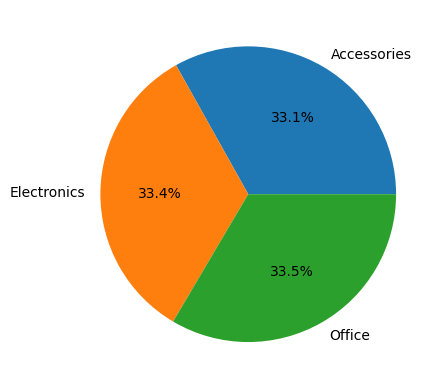

In [33]:
plt.pie(
    sales_df["Sales"],
    labels=sales_df["Category"],
    autopct="%2.1f%%"
)

plt.show()

In [47]:
def plot_pie_for_profit_sales(df:pd.DataFrame, group_by_col:str):
    sales_df = df.groupby(group_by_col)["Sales"].mean().reset_index()
    profit_df = df.groupby(group_by_col)["Profit"].mean().reset_index()
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].pie(
        sales_df["Sales"],
        labels=sales_df[group_by_col],
        autopct="%2.1f%%",
    )
    ax[0].set_title(f"Average Sales by {group_by_col}")
    
    ax[1].pie(
        profit_df["Profit"],
        labels=sales_df[group_by_col],
        autopct="%2.1f%%",
    )
    ax[1].set_title(f"Average Profit by {group_by_col}")

    plt.tight_layout()
    plt.show()

In [48]:
df.columns

Index(['Product Name', 'Category', 'Region', 'Quantity', 'Sales', 'Profit',
       'order_date'],
      dtype='object')

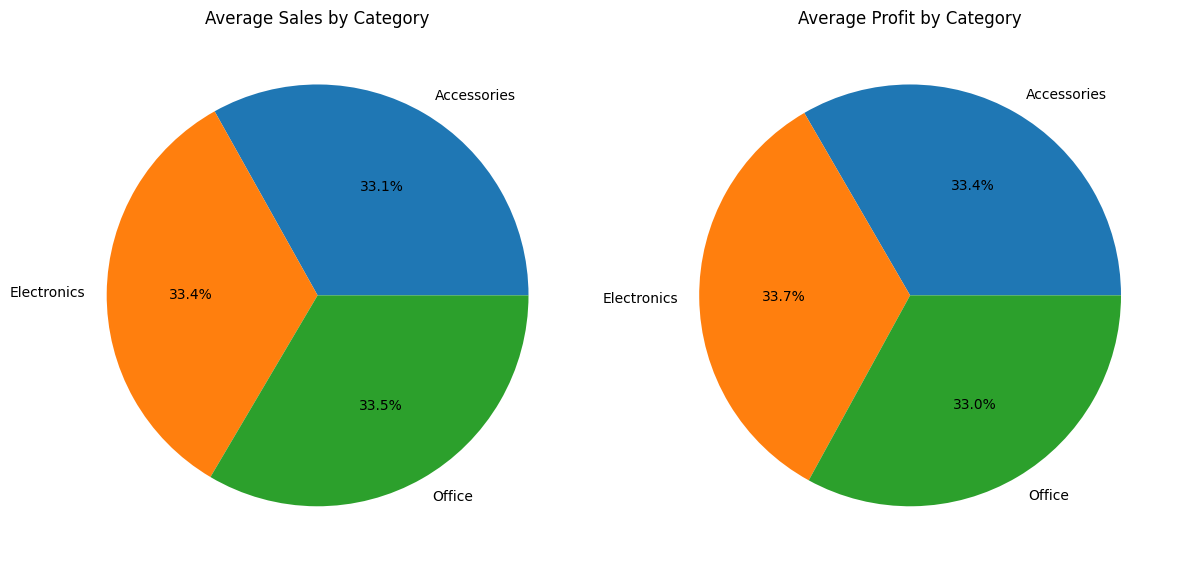

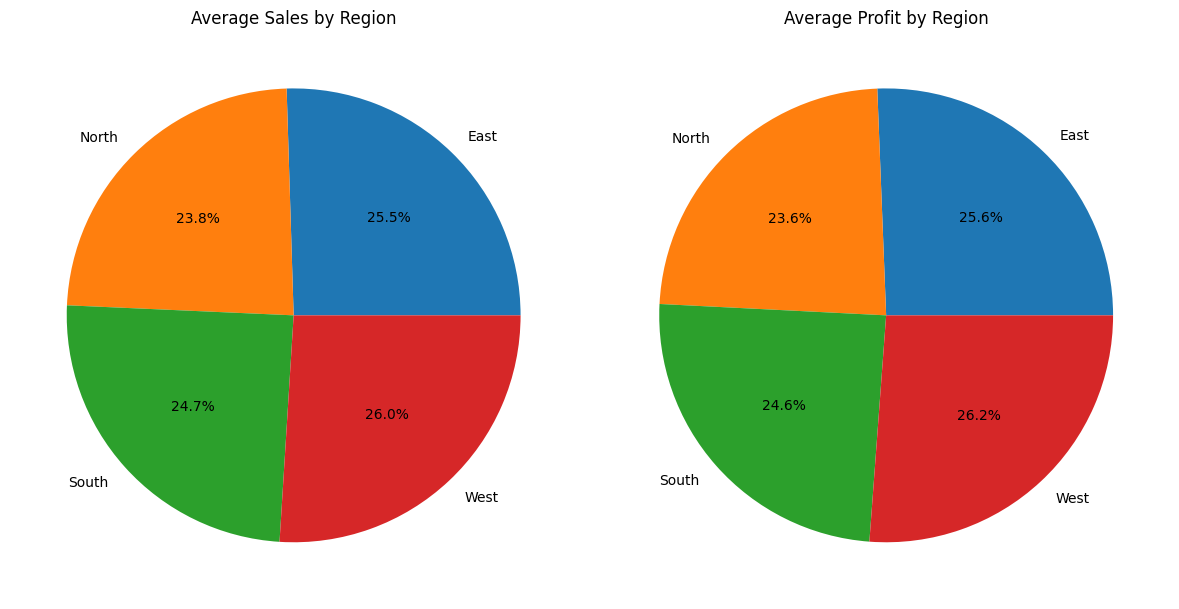

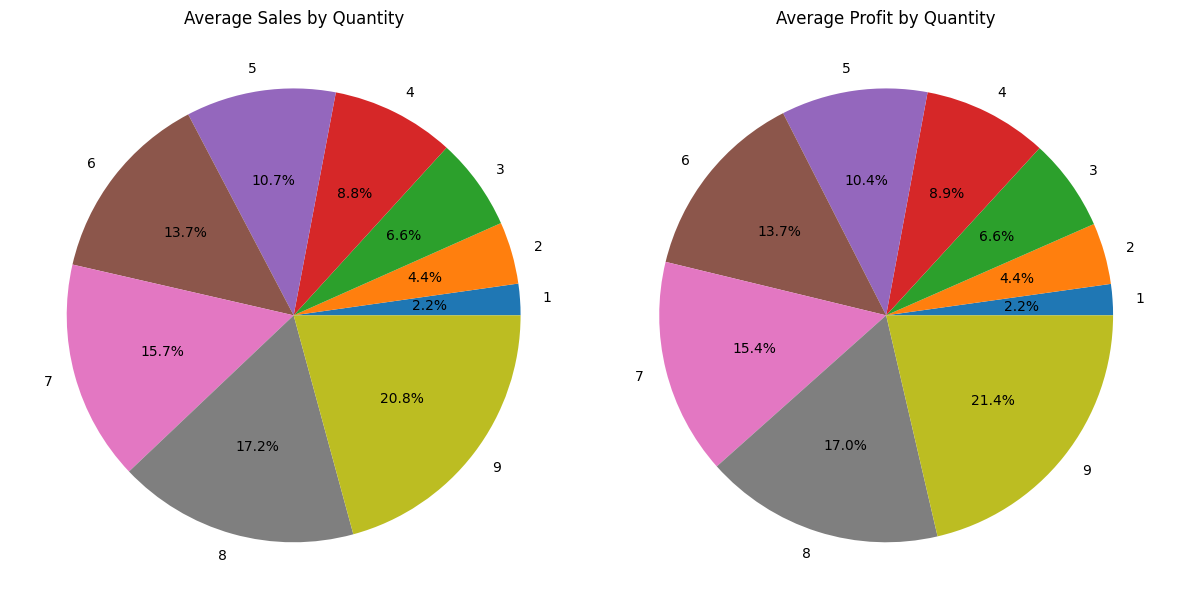

In [49]:
for col in ['Category', 'Region', 'Quantity']:
    plot_pie_for_profit_sales(df, group_by_col=col)

- Very similar data points.
- I knew this is dummy data but their are no any variation
- So I stop doing EDA
- And go for dinner.
- 21-02-2026 